#### Name: Solution

# PHYS 230 Lab Assignment 10

### Wednesday, February 25, 2026: Chapter 5.10-5.12
- Evaluating derivatives in python 
- Interpolation 

In [11]:
# put all import statements here
import numpy as np
import math
import matplotlib.pyplot as plt

## Derivatives with front, back, and central difference (25 pts)

Let's evaluate the derivative of: 

$$ f(x) = \frac{1-\cos x}{x^2} $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the function `f(x)` that returns the function $f(x)$ from above. 

In [12]:
# define function to take derivative of 
def f(x):
    return (1-np.cos(x))/x**2

#### Step 2: Define functions that call on your function from step 1 to calculate the front, back, and central difference first derivatives of $f(x)$ at a specific location $x$. 

In [13]:
# forward difference 
def calc_fd(f,x,h):
    fd = (f(x+h) - f(x))/h
    return fd

# backward difference 
def calc_bd(f,x,h):
    bd = (f(x) - f(x-h))/h
    return bd

# central difference 
def calc_cd(f,x,h):
    cd = (f(x+h/2)-f(x-h/2))/h
    return cd

#### Step 3: Evaluate the derivative using the three different approximations using the appropriate value of $h$ for each method evaluated from $x = 0.004$ to $x = \frac{\pi}{2}$ - let's do 20 calculations. 

In [14]:
# create array of x-values to ealuate 
vals = np.linspace(0.004,np.pi/2, 20)

# define zero arrays to fill in using function 
derv_fd = np.zeros(20)
derv_bd = np.zeros(20)
derv_cd = np.zeros(20)
# define appropariate h values for forward/backward difference and central difference 
h_fd = 1e-8
h_cd = 1e-5

# evaluate derivatives using functions from above 
for i in range(20):
    derv_fd[i] = calc_fd(f,vals[i], h_fd)
    derv_bd[i] = calc_bd(f,vals[i], h_fd)
    derv_cd[i] = calc_cd(f,vals[i], h_cd)  

#### Step 4: Determine the equation for the derivative (by hand and then type in below this cell as markdown). Computationally calculate the true value of the derivative at the range of values from step 3 and compare to your calculated values. Explain your results in a markdown cell. 

$$\frac{df}{dx} = \frac{(x\sin(x)+2\cos(x)-2)}{x^3} $$

In [15]:
# define true derivative equation 
def fprime(x):
    return (x*np.sin(x)+2*np.cos(x)-2)/x**3

# call on function to calculate actual values of derivative for each x value 
actual_vals = np.zeros(20)
for i in range(20):
    actual_vals[i] = fprime(vals[i])
    
#print("from front difference", derv_fd)
#print("from back difference",derv_bd)
#print("from central difference",derv_cd)
#print("actual",actual_vals)

# print out results for all 
rowf = "{0:1.5f} {1:1.16f} {2:1.16f} {3:1.16f} {4:1.16f}"
print("x_val          Forward            Backward           Central            actual ")
for i in range(20):
    print( rowf.format(vals[i], derv_fd[i],derv_bd[i], derv_cd[i], actual_vals[i]))

x_val          Forward            Backward           Central            actual 
0.00400 0.0000415223411210 -0.0007212619390629 -0.0003336258658226 -0.0003333340548028
0.08646 -0.0072017447561024 -0.0072004124884728 -0.0072016567431721 -0.0072016567463480
0.16893 -0.0140503386703017 -0.0140503775281076 -0.0140504008483422 -0.0140504008604181
0.25139 -0.0208609296503681 -0.0208609574059437 -0.0208609633345347 -0.0208609633668820
0.33385 -0.0276148326427972 -0.0276148492961426 -0.0276148813205257 -0.0276148812914264
0.41631 -0.0342939232567119 -0.0342938732966758 -0.0342938977826446 -0.0342938977411364
0.49878 -0.0408799882833932 -0.0408800437945445 -0.0408800281237465 -0.0408800281345417
0.58124 -0.0473556360791605 -0.0473556360791605 -0.0473556252822416 -0.0473556252814260
0.66370 -0.0537034472447573 -0.0537034527958724 -0.0537034430259098 -0.0537034430382131
0.74617 -0.0599066962703176 -0.0599067018214328 -0.0599066982687191 -0.0599066982714708
0.82863 -0.0659491294907610 -0.0659491405

Overall, all values seem to be fairly close to the actual value. Since each is using the appropriate $h$ value, we would expect them to be fairly accurate. If we compared the error of each (compared to the actual), we would probably find that the central difference is the most accurate. 

#### Step 5: Evalute the derivative using the three approximations with a value of $h=10^{-6}$. Compare (computationally and in markdown) the values with each other and the true value. 

In [16]:
# define the h value
h = 1e-6
# use functions to calculate derivatives using each method 
for i in range(20):
    derv_fd[i] = calc_fd(f,vals[i], h)
    derv_bd[i] = calc_bd(f,vals[i], h)
    derv_cd[i] = calc_cd(f,vals[i], h)
    
# print out the value and the error when compared to the actual value 
rowf = "{0:1.16f} {1:1.16f}"
for i in range(20):
    print("   ")
    print("For x = ", vals[i])
    print("Forward difference: calculation    error")
    print( rowf.format(derv_fd[i], abs(derv_fd[i]-actual_vals[i])))
    print("Backward difference: calculation    error")
    print( rowf.format(derv_bd[i], abs(derv_bd[i]-actual_vals[i])))        
    print("Central difference: calculation    error")
    print( rowf.format(derv_cd[i], abs(derv_cd[i]-actual_vals[i])))


   
For x =  0.004
Forward difference: calculation    error
-0.0003299469031326 0.0000033871516703
Backward difference: calculation    error
-0.0003359194034047 0.0000025853486019
Central difference: calculation    error
-0.0003329334585800 0.0000004005962229
   
For x =  0.08646296456815246
Forward difference: calculation    error
-0.0072017040109174 0.0000000472645694
Backward difference: calculation    error
-0.0072016125285401 0.0000000442178079
Central difference: calculation    error
-0.0072016508867456 0.0000000058596024
   
For x =  0.16892592913630491
Forward difference: calculation    error
-0.0140504414769538 0.0000000406165357
Backward difference: calculation    error
-0.0140503587098273 0.0000000421505908
Central difference: calculation    error
-0.0140504018419918 0.0000000009815737
   
For x =  0.2513888937044574
Forward difference: calculation    error
-0.0208610037577550 0.0000000403908730
Backward difference: calculation    error
-0.0208609231555634 0.0000000402113185

/var/folders/_7/3rpl5gcd2bg758cn3lr13thn8wg2tc/T/ipykernel_41403/128234500.py:3: RuntimeWarning: invalid value encountered in divide
  return (1-np.cos(x))/x**2


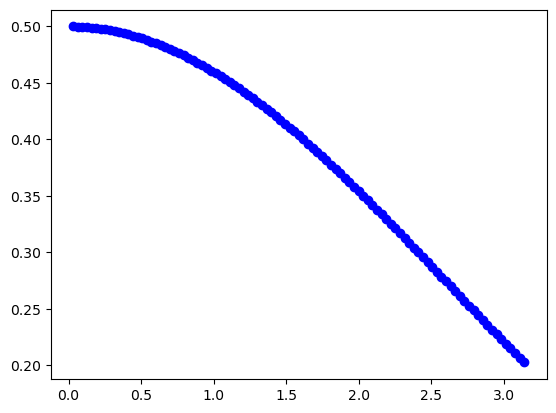

In [17]:
# to compare, can make a plot of the function to see why 
#there are issues at x=0.004 for forward difference 
x_arr = np.linspace(0.00,np.pi,100)
y = f(x_arr)

# plot the function 
import matplotlib.pyplot as plt
plt.plot(x_arr,y,'bo')

**Comparison:** The function becomes undefined at $x=0$, and this is why the evluation at the first point is perhaps inconsistent. 

Overall, the error for the central difference calculations is the smallest. 

## Second derivative (25 pts)

Let's take the second derivative of the function from above. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define functions that call on your function from step 1 above to calculate the second derivative of $f(x)$ at a specific location $x$ using central difference. 

In [23]:
# create function to accomplish the second derivative using central difference 
def second_deriv(f,x,h):
    second_cd = (f(x+h)-2*f(x)+f(x-h))/h**2
    return second_cd

#### Step 2: Evalute the second derivative at $x = 0.004$ using a range of $h$ values from `1e-1` to `1e-12`. 

In [24]:
# define variables 
x = 0.004
hs = [10**(-i) for i in range(1,12)]
print(hs)

# create zeros array and calculate the second derivative 
deriv2_cd = np.zeros(len(hs)) 
for i in range(len(hs)):
    deriv2_cd[i] = second_deriv(f,x,hs[i])
    
print(deriv2_cd)

[0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07, 1e-08, 1e-09, 1e-10, 1e-11]
[-8.33052937e-02 -8.33327691e-02 -8.33309348e-02 -8.32469316e-02
 -6.39432951e-02  5.97250027e+00 -4.95381514e+01  7.62784280e+04
 -6.25610674e+04 -6.66133815e+04 -5.55111512e+05]


#### Step 3: Determine the equation for the derivative (by hand/WolframAlpha and then type in below this cell as markdown). Calculate the true value of the derivative at $x = 0.004$.  

$$ \frac{d^2}{dx^2}f(x) = \frac{6(1-\cos(x))}{x^4}+\frac{\cos(x)}{x^2} + \frac{-4\sin(x)}{x^3} $$

In [25]:
# define function that is 
def fdoubleprime(x):
    val1 = 6*(1-np.cos(x))/x**4
    val2 = np.cos(x)/x**2
    val3 = -4*np.sin(x)/x**3
    val = val1 + val2 + val3
    return val

# call function and print result 
true_deriv2 = fdoubleprime(x)
print(true_deriv2)

-0.08333355362992734


#### Step 4: Computationally compare your calculated answer to the true value for each $h$ value. Include a markdown explaining the process and result.

In [26]:
print("the true value of the derivative is: ", true_deriv2)
print("h value      derivative value       abs. err")
rowf = "{0:1.0e}   {1:1.16f}     {2:1.16f}"
for i in range(len(hs)):
    print(rowf.format(hs[i], deriv2_cd[i], np.abs(deriv2_cd[i]-true_deriv2)))

the true value of the derivative is:  -0.08333355362992734
h value      derivative value       abs. err
1e-01   -0.0833052937079359     0.0000282599219914
1e-02   -0.0833327690685781     0.0000007845613492
1e-03   -0.0833309347636479     0.0000026188662794
1e-04   -0.0832469315703577     0.0000866220595697
1e-05   -0.0639432951032859     0.0193902585266415
1e-06   5.9725002721222609     6.0558338257521882
1e-07   -49.5381513587744919     49.4548178051445646
1e-08   76278.4280183836817741     76278.5113519373117015
1e-09   -62561.0674376275637769     62560.9841040739338496
1e-10   -66613.3814775093924254     66613.2981439557624981
1e-11   -555111.5123125782702118     555111.4289790246402845


We can see that as we go to smaller values of $h$ the error becomes quite large. The smallest error is achieved when $h = 1\times10^{-2}$. 

## Automatic Differentiation 

Let's use the method of automatic differentation to determine the value for both the function 

$f(x) = x+\tan(\cos^2x+\sin^2x)$ 

and its derivative at $x = 0$ (or at $t = 0$ as described in class). Do so using the following steps. 

a) Write a Python function `f(x)` to compute the function value and derivative of a list $x$ using automatic differentiation. [Hint: you will need a few additional functions as well -> look at the class notebook example]

b) Make a plot of the function $f(x)$ vs. $x$ over the range of $-\pi$ to $\pi$ that you will be able to compare with your results in part c. 

c) Use your function determine the function and dervative values at $x = 0$ ($t=0$). Remember, that your list should be entered as `[t,1]`. How do you results compare with part b? Add a markdown cell to explain your process and compare your answer with your graph from part b. 


Hint: If you program is taking a long time to run, then you are probably doing the calculation the wrong way. It should only take a second or two to finish.

In [ ]:
## part a
def power(x,c):
    vx,dx = x
    return [vx**c, c*vx**(c-1)*dx]

def sine(x):
    vx,dx = x
    return [math.sin(vx), -dx*math.cos(vx)]

def cosine(x):
    vx,dx = x
    return [math.cos(vx), dx*math.sin(vx)]

def tangent(x):
    vx,dx = x
    return [math.tan(vx), dx/(math.cos(vx))**2]

def add(x,y):
    vx,dx = x
    vy,dy = y
    return [vx+vy, dx+dy]

def f(x):
    u1 = cosine(x)
    print(u1)
    u2 = sine(x)
    print(u2)
    u3 = power(u1,2)
    print(u3)
    u4 = power(u2,2)
    print(u4)
    u5 = add(u3,u4)
    print(u5)
    u6 = tangent(u5)
    print(u6)
    u7 = add(x,u6)
    print(u7)
    return(u7)


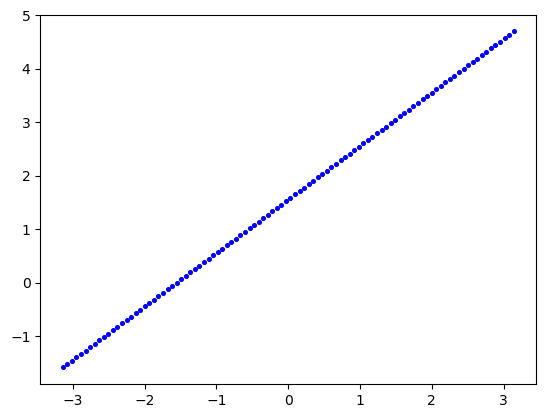

In [ ]:
# part b
x = np.linspace(-np.pi, np.pi, 100)
y = x + np.tan(np.cos(x)**2+np.sin(x)**2)
plt.scatter(x,y,c="b", s=7)

In [ ]:
## part c
print(f([0,1]))

#### Compare

## Automatic Differentation ( pts) - **DID NOT DO THIS BUT SAVING IN CASE FOR FUTURE**

Let's apply the concept of automatic differentation to find the value of both the function and its derivative. 

Let's evaluate 

Hermite polynomials, $H_n(x)$, are used in deteremining the wavefunction of the 𝑛th energy level of the one-dimensional quantum harmonic oscillator—i.e., a spinless point particle in a quadratic potential well, which is given by
$$ \psi_n(s) = \frac{1}{\sqrt{2^n n! \sqrt{\pi}}} e^{-x^2/2} H_n(x)$$
for $n = 0, ..., \infty$, in units where all constants are 1, and where $H_n(x)$ is the 𝑛th Hermite polynomial. Hermite polynomials satisfy a
relation somewhat similar to that for Fibonacci numbers, although more complex:


$$H_{n+1}(x) = 2xH_n(x) - 2nH_{n-1}(x), \hspace{0.2in} \text{with} \hspace{0.2in} H_0(x) = 1 \hspace{0.1in} \text{and} \hspace{0.1in} H_1(x) = 2x.$$


a) Write a Python function `H(n,x)` to compute the value and derivative of the 𝑛th Hermite polynomial at the point $x$ using automatic differentiation. [Hint: you will need an `add` and `multiply` functions as well, but all with 2D -> look at the class notebook example]

b) Use your function to verify the values of the derivatives $H'_3(\frac{1}{2}) = -6$ and $H'_{10}(\frac{1}{2}) = 129,620$

c) Make a plot of the derivative of $H_{100}(x)$ between $x = -2$ and $x = 2$. 

Hint: If you program is taking a long time to run, then you are probably doing the calculation the wrong way. It should only take a second or two to finish.

In [ ]:
# part a 

def add(x,y):
    vx,dx = x
    vy,dy = y
    return [vx+vy, dx+dy]

def multiply(x,y):
    vx,dx = x
    vy,dy = y
    return [vx*vy, vx*dy+vy*dx]

# function to calculate Hermite polynomial and derivative 
def H(n,x):
    

$f(x) = x+\tan(\cos^2x+\sin^2x)$ 

at x = 0


$p(x) = x^3 + x^2 + x +1$
at $x = 3$ 

In [4]:
def power(x,c):
    vx,dx = x
    return [vx**c, c*vx**(c-1)*dx]

def sine(x):
    vx,dx = x
    return [math.sin(vx), -dx*math.cos(vx)]

def cosine(x):
    vx,dx = x
    return [math.cos(vx), dx*math.sin(vx)]

def tangent(x):
    vx,dx = x
    return [math.tan(vx), dx/(math.cos(vx))**2]

def add(x,y):
    vx,dx = x
    vy,dy = y
    return [vx+vy, dx+dy]

def f(x):
    u1 = cosine(x)
    print(u1)
    u2 = sine(x)
    print(u2)
    u3 = power(u1,2)
    print(u3)
    u4 = power(u2,2)
    print(u4)
    u5 = add(u3,u4)
    print(u5)
    u6 = tangent(u5)
    print(u6)
    u7 = add(x,u6)
    print(u7)
    return(u7)

print(f([0,1]))

[1.0, 0.0]
[0.0, -1.0]
[1.0, 0.0]
[0.0, -0.0]
[1.0, 0.0]
[1.557407724654902, 0.0]
[1.557407724654902, 1.0]
[1.557407724654902, 1.0]



> Dual(1.557407724654902, 1.0)